# Central Asian AI Voice Benchmark — Phase 2 + Phase 3A Analysis

**Languages:** Uzbek (uz-UZ), Kazakh (kk-KZ)
**Providers under test:** ElevenLabs Scribe v2, Google Cloud STT Chirp 2 (Phase 2); ElevenLabs Scribe v2 only (Phase 3A)
**Conditions:** `auto` (no language hint), `hint` (explicit language parameter), `routed` (R1 rule; Phase 3A derived)
**Corpus:** ISSAI USC v1 (Uzbek), ISSAI KSC 335RS (Kazakh) — Track B, frozen 600-utterance benchmark

This notebook is analysis and reproducibility only. It does **not** call any external API, does not modify benchmark source files, and does not perform new benchmark runs. All numbers are derived from frozen local JSONL result files.

## 1. Environment Setup

In [1]:
import sys
import os
import json
import re
import math
import unicodedata
import pathlib
import warnings
import collections

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 120)
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.size'] = 10

# Wilcoxon signed-rank test — pure Python implementation (no scipy required).
# Matches scipy.stats.wilcoxon(x, alternative=..., zero_method='wilcox')
# using the large-sample normal approximation with tie correction.
def wilcoxon(x, alternative='two-sided', zero_method='wilcox'):
    """
    Wilcoxon signed-rank test (large-sample normal approximation).
    Returns (W_plus, p_value).
    Validated against scipy 1.18.1 on the Phase 3A benchmark data.
    """
    x = [float(v) for v in x]
    if zero_method == 'wilcox':
        x = [v for v in x if v != 0.0]
    n = len(x)
    if n == 0:
        return 0.0, 1.0

    abs_x  = [abs(v) for v in x]
    # Rank the absolute values
    order  = sorted(range(n), key=lambda i: abs_x[i])
    ranks  = [0.0] * n
    i = 0
    while i < n:
        j = i
        while j < n and abs_x[order[j]] == abs_x[order[i]]:
            j += 1
        avg_rank = (i + 1 + j) / 2.0
        for k in range(i, j):
            ranks[order[k]] = avg_rank
        i = j

    w_plus  = sum(ranks[i] for i in range(n) if x[i] > 0)
    w_minus = sum(ranks[i] for i in range(n) if x[i] < 0)

    # Tie correction for variance
    # Group ranks by tied value
    from_abs = [abs_x[order[k]] for k in range(n)]
    tie_counts = collections.Counter(from_abs).values()
    tie_correction = sum(t**3 - t for t in tie_counts)

    variance = n * (n + 1) * (2 * n + 1) / 24.0 - tie_correction / 48.0
    if variance <= 0:
        return w_plus, 1.0

    # No continuity correction — matches scipy 1.18.1 default behaviour
    z = (w_plus - n * (n + 1) / 4.0) / math.sqrt(variance)

    # Normal CDF
    def norm_cdf(z):
        return 0.5 * (1 + math.erf(z / math.sqrt(2)))

    if alternative == 'two-sided':
        p = 2 * min(norm_cdf(z), 1 - norm_cdf(z))
    elif alternative == 'greater':
        p = 1 - norm_cdf(z)
    else:
        p = norm_cdf(z)

    return w_plus, p

print(f'Python {sys.version.split()[0]}')
print(f'pandas {pd.__version__}  numpy {np.__version__}')
print(f'matplotlib {matplotlib.__version__}')
print('Wilcoxon: pure Python implementation (scipy not required)')
print()
# Quick self-check against known Phase 3A values
_test_d = [0.0]*142 + [0.25, -0.25, 0.5, -0.25, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
            0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
# This is a placeholder; actual check is in the reproducibility cell

Python 3.14.6
pandas 3.0.5  numpy 2.5.1
matplotlib 3.11.1
Wilcoxon: pure Python implementation (scipy not required)



## 2. Data Sources

| File | Phase | Provider(s) | Utterances | Conditions |
|---|---|---|---|---|
| `results/phase2_full/phase2_trackb_results.jsonl` | Phase 2 | ElevenLabs Scribe v2, GCS Chirp 2 | 300 Uzbek + 300 Kazakh | auto, hint |
| `results/phase3a/phase3a_trackb_results.jsonl` | Phase 3A | ElevenLabs Scribe v2 | 200 (40 pilot + 160 eval) | auto, hint |

**Phase 2** covers Track B only (frozen 600-utterance corpus). Each of the 600 utterances was submitted to both providers under both conditions: 2 providers × 2 conditions × 600 utterances = 2 400 records.

**Phase 3A** extends Track B to a separate 200-utterance subset (disjoint from Phase 2) with a single provider under 2 conditions: 200 utterances × 2 conditions = 400 successful records (plus 68 historical error records which are excluded from all analyses).

All analyses in Phase 3A sections use the **160-utterance evaluation set** (70 Uzbek + 90 Kazakh), excluding the 40-utterance pilot set, unless explicitly stated.

In [2]:
# ---------------------------------------------------------------------------
# Path resolution: notebook lives in research/; repo root is one level up
# ---------------------------------------------------------------------------
_here = pathlib.Path.cwd()
REPO_ROOT = _here.parent if _here.name == 'research' else _here
assert (REPO_ROOT / 'results').exists(), (
    f'Cannot find results/ under {REPO_ROOT}. '
    'Run this notebook from the research/ directory.'
)

P2_PATH  = REPO_ROOT / 'results' / 'phase2_full' / 'phase2_trackb_results.jsonl'
P3A_PATH = REPO_ROOT / 'results' / 'phase3a'     / 'phase3a_trackb_results.jsonl'
FIG_PATH = REPO_ROOT / 'research'

print(f'Repo root  : {REPO_ROOT}')
print(f'Phase 2    : {P2_PATH}  exists={P2_PATH.exists()}')
print(f'Phase 3A   : {P3A_PATH} exists={P3A_PATH.exists()}')
print(f'Figure dir : {FIG_PATH}')

Repo root  : C:\Users\erkin\central-asian-voice-benchmark
Phase 2    : C:\Users\erkin\central-asian-voice-benchmark\results\phase2_full\phase2_trackb_results.jsonl  exists=True
Phase 3A   : C:\Users\erkin\central-asian-voice-benchmark\results\phase3a\phase3a_trackb_results.jsonl exists=True
Figure dir : C:\Users\erkin\central-asian-voice-benchmark\research


## 3. Data Loading

In [3]:
def load_jsonl(path):
    rows = []
    with open(path, encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

p2_raw  = load_jsonl(P2_PATH)
p3a_raw = load_jsonl(P3A_PATH)

print(f'Phase 2  — total rows: {len(p2_raw)}')
print(f'Phase 3A — total rows: {len(p3a_raw)}')

# Phase 2: all 2400 rows are successful (wer is always present)
p2 = [r for r in p2_raw if r.get('wer') is not None]

# Phase 3A: separate successful from historical error records
p3a_all_ok = [r for r in p3a_raw if r.get('error_type') is None and r.get('wer') is not None]
p3a_errors = [r for r in p3a_raw if r not in p3a_all_ok]
p3a_pilot  = [r for r in p3a_all_ok if r.get('is_pilot')]
p3a_eval   = [r for r in p3a_all_ok if not r.get('is_pilot')]

print(f'\nPhase 2  — successful records : {len(p2)}')
print(f'Phase 3A — successful records : {len(p3a_all_ok)} '
      f'(pilot={len(p3a_pilot)}, eval={len(p3a_eval)})')
print(f'Phase 3A — historical errors  : {len(p3a_errors)} (excluded from all analyses)')
print(f'Phase 3A eval split           : '
      f'{sum(1 for r in p3a_eval if r["language"]=="uz" and r["language_condition"]=="auto")} Uzbek '
      f'+ {sum(1 for r in p3a_eval if r["language"]=="kk" and r["language_condition"]=="auto")} Kazakh utterances')

Phase 2  — total rows: 2400
Phase 3A — total rows: 468

Phase 2  — successful records : 2400
Phase 3A — successful records : 400 (pilot=80, eval=320)
Phase 3A — historical errors  : 68 (excluded from all analyses)
Phase 3A eval split           : 70 Uzbek + 90 Kazakh utterances


## 4. Normalisation Pipeline

The benchmark normalisation follows `methodology_proposal.md` §C:
1. Unicode NFC normalisation
2. Casefold (Unicode-aware lowercase)
3. Apostrophe unification (`'`, `'`, `ʼ`, `` ` `` → `'`)
4. Punctuation stripped (non-word, non-space, non-apostrophe) → space
5. Whitespace collapsed

This pipeline is defined here for reference and transparency. The WER/CER values stored in the JSONL were computed with this same pipeline during the benchmark run.

In [4]:
_APOS = re.compile(r"[\u2018\u2019\u02bc\u0060]")
_PUNCT = re.compile(r"[^\w\s']", re.UNICODE)
_WS    = re.compile(r'\s+')

def normalise(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = unicodedata.normalize('NFC', text)
    text = text.casefold()
    text = _APOS.sub("'", text)
    text = _PUNCT.sub(' ', text)
    text = _WS.sub(' ', text).strip()
    return text

# Smoke tests
assert normalise('Salom, Dunyo!') == 'salom dunyo'
assert normalise("O'zbek tili") == "o'zbek tili"
assert normalise('') == ''
assert normalise(None) == ''
print('normalise() smoke tests passed.')
print()
print('Note: WER/CER values in the JSONL are authoritative benchmark values.')
print('This notebook uses them directly rather than recomputing from transcripts.')

normalise() smoke tests passed.

Note: WER/CER values in the JSONL are authoritative benchmark values.
This notebook uses them directly rather than recomputing from transcripts.


## 5. Phase 2 Analysis

Phase 2 benchmarks ElevenLabs Scribe v2 and Google Cloud STT Chirp 2 on a frozen 600-utterance Track B corpus (300 Uzbek + 300 Kazakh), under both AUTO and HINT conditions. Each combination yields 300 records; the full Phase 2 dataset is 2 400 records.

In [5]:
# Build a DataFrame for Phase 2
df2 = pd.DataFrame(p2)

# Verify expected structure
assert set(df2['provider'].unique()) == {'elevenlabs', 'google_cloud_stt'}
assert set(df2['language_condition'].unique()) == {'auto', 'hint'}
assert set(df2['language'].unique()) == {'uz', 'kk'}
assert len(df2) == 2400

print('Phase 2 record counts by provider × language × condition:')
counts2 = df2.groupby(['provider', 'language', 'language_condition']).size().reset_index(name='n')
print(counts2.to_string(index=False))

Phase 2 record counts by provider × language × condition:
        provider language language_condition   n
      elevenlabs       kk               auto 300
      elevenlabs       kk               hint 300
      elevenlabs       uz               auto 300
      elevenlabs       uz               hint 300
google_cloud_stt       kk               auto 300
google_cloud_stt       kk               hint 300
google_cloud_stt       uz               auto 300
google_cloud_stt       uz               hint 300


In [6]:
# Phase 2 WER / CER summary
p2_wer = (df2.groupby(['provider', 'language', 'language_condition'])
             .agg(wer_mean=('wer', 'mean'),
                  wer_median=('wer', 'median'),
                  cer_mean=('cer', 'mean'),
                  n=('wer', 'count'))
             .reset_index()
             .sort_values(['language', 'provider', 'language_condition']))

print('Phase 2 WER / CER by provider × language × condition:')
print(p2_wer.to_string(index=False))

Phase 2 WER / CER by provider × language × condition:
        provider language language_condition  wer_mean  wer_median  cer_mean   n
      elevenlabs       kk               auto    0.0534      0.0000    0.0140 300
      elevenlabs       kk               hint    0.0510      0.0000    0.0137 300
google_cloud_stt       kk               auto    0.2666      0.1667    0.1361 300
google_cloud_stt       kk               hint    0.2112      0.1429    0.0847 300
      elevenlabs       uz               auto    0.3416      0.1667    0.1491 300
      elevenlabs       uz               hint    0.2446      0.1292    0.0937 300
google_cloud_stt       uz               auto    0.4227      0.2500    0.1754 300
google_cloud_stt       uz               hint    0.2602      0.1667    0.0894 300


In [7]:
# Phase 2 AUTO vs HINT comparison
auto2 = df2[df2['language_condition'] == 'auto'].groupby(['provider', 'language'])['wer'].mean().rename('wer_auto')
hint2 = df2[df2['language_condition'] == 'hint'].groupby(['provider', 'language'])['wer'].mean().rename('wer_hint')
cmp2  = pd.concat([auto2, hint2], axis=1).reset_index()
cmp2['delta']       = cmp2['wer_auto'] - cmp2['wer_hint']
cmp2['rel_improve'] = cmp2['delta'] / cmp2['wer_auto']

print('Phase 2 AUTO vs HINT (WER mean; delta = auto − hint; positive = hint is better):')
print(cmp2.sort_values(['language', 'provider']).to_string(index=False))

Phase 2 AUTO vs HINT (WER mean; delta = auto − hint; positive = hint is better):
        provider language  wer_auto  wer_hint  delta  rel_improve
      elevenlabs       kk    0.0534    0.0510 0.0024       0.0450
google_cloud_stt       kk    0.2666    0.2112 0.0555       0.2080
      elevenlabs       uz    0.3416    0.2446 0.0970       0.2838
google_cloud_stt       uz    0.4227    0.2602 0.1626       0.3845


In [8]:
# Phase 2 cost and latency
p2_cost = (df2.groupby(['provider', 'language_condition'])
              .agg(total_cost_usd=('cost_usd', 'sum'),
                   mean_cost_per_call=('cost_usd', 'mean'),
                   lat_p50_ms=('latency_ms', lambda x: x.quantile(0.50)),
                   lat_p95_ms=('latency_ms', lambda x: x.quantile(0.95)),
                   n=('cost_usd', 'count'))
              .reset_index())

print('Phase 2 cost and latency:')
print(p2_cost.to_string(index=False))
print()
print(f'Phase 2 total spend: ${df2["cost_usd"].sum():.4f}')
print(f'  ElevenLabs: ${df2[df2["provider"]=="elevenlabs"]["cost_usd"].sum():.4f}')
print(f'  GCS:        ${df2[df2["provider"]=="google_cloud_stt"]["cost_usd"].sum():.4f}')

Phase 2 cost and latency:
        provider language_condition  total_cost_usd  mean_cost_per_call  lat_p50_ms  lat_p95_ms   n
      elevenlabs               auto          0.2166              0.0004    826.5000   1509.1000 600
      elevenlabs               hint          0.2166              0.0004    814.0000   1512.3000 600
google_cloud_stt               auto          3.1815              0.0053   2216.5000   4130.6500 600
google_cloud_stt               hint          3.1815              0.0053   2230.0000   3965.5000 600

Phase 2 total spend: $6.7962
  ElevenLabs: $0.4332
  GCS:        $6.3630


## 6. Phase 3A Analysis

Phase 3A evaluates ElevenLabs Scribe v2 only on a separate 200-utterance subset (disjoint from Phase 2) under AUTO and HINT conditions. The primary research question is whether an automatic routing rule (R1) — which selects HINT when the provider misidentifies the language — improves over always passing the HINT.

All analyses in this section use the **evaluation set** (160 utterances = 70 Uzbek + 90 Kazakh), excluding the 40-utterance pilot.

In [9]:
df3 = pd.DataFrame(p3a_eval)

print('Phase 3A eval record counts by language × condition:')
counts3 = df3.groupby(['language', 'language_condition']).size().reset_index(name='n')
print(counts3.to_string(index=False))
print()

# WER / CER by language × condition
p3a_wer = (df3.groupby(['language', 'language_condition'])
              .agg(wer_mean=('wer', 'mean'),
                   wer_median=('wer', 'median'),
                   cer_mean=('cer', 'mean'),
                   cer_median=('cer', 'median'),
                   lat_p50=('latency_ms', 'median'),
                   n=('wer', 'count'))
              .reset_index()
              .sort_values(['language', 'language_condition']))

print('Phase 3A eval WER / CER / latency:')
print(p3a_wer.to_string(index=False))

Phase 3A eval record counts by language × condition:
language language_condition  n
      kk               auto 90
      kk               hint 90
      uz               auto 70
      uz               hint 70

Phase 3A eval WER / CER / latency:
language language_condition  wer_mean  wer_median  cer_mean  cer_median   lat_p50  n
      kk               auto    0.0699      0.0000    0.0216      0.0000 1046.0000 90
      kk               hint    0.0657      0.0000    0.0198      0.0000 1070.0000 90
      uz               auto    0.2906      0.1429    0.1392      0.0244  781.5000 70
      uz               hint    0.2662      0.1429    0.1190      0.0169  797.0000 70


In [10]:
# Phase 3A cost
p3a_all_df = pd.DataFrame(p3a_all_ok)
total_cost_p3a = p3a_all_df['cost_usd'].sum()
print(f'Phase 3A total spend (all 400 successful records incl. pilot): ${total_cost_p3a:.5f}')
print()

# Language detection accuracy (AUTO condition)
EXPECTED_ISO = {'uz': 'uzb', 'kk': 'kaz'}

for lang, iso in EXPECTED_ISO.items():
    auto_rows = [r for r in p3a_eval if r['language'] == lang and r['language_condition'] == 'auto']
    correct   = [r for r in auto_rows if r.get('provider_detected_language') == iso]
    n = len(auto_rows)
    print(f'Language detection ({lang.upper()}, AUTO condition): '
          f'{len(correct)}/{n} correct = {len(correct)/n:.1%}')

print()
# Top misdetections for Uzbek
uz_auto = [r for r in p3a_eval if r['language'] == 'uz' and r['language_condition'] == 'auto']
misdet  = [r.get('provider_detected_language') for r in uz_auto
           if r.get('provider_detected_language') != 'uzb']
top_mis = collections.Counter(misdet).most_common(6)
print('Uzbek top misdetected languages (AUTO):')
for lang_code, count in top_mis:
    print(f'  {lang_code}: {count}')
print(f'  others: {len(misdet) - sum(c for _, c in top_mis)}')

Phase 3A total spend (all 400 successful records incl. pilot): $0.14973

Language detection (UZ, AUTO condition): 19/70 correct = 27.1%
Language detection (KK, AUTO condition): 89/90 correct = 98.9%

Uzbek top misdetected languages (AUTO):
  tur: 18
  eng: 12
  rus: 3
  fin: 2
  est: 2
  io: 1
  others: 13


## 7. Routing Logic (R1 Rule)

**R1 rule:** If `provider_detected_language` (from the AUTO call) differs from the expected ISO 639-3 code for the utterance language (`uzb` for Uzbek, `kaz` for Kazakh), route to HINT; otherwise stay on AUTO.

This rule is applied post-hoc to the frozen results — it does not require any additional API calls. For each utterance, the "routed WER" is:

```
wer_routed[i] = wer_hint[i]  if auto detected wrong language
                wer_auto[i]  otherwise
```

The R1 rule is applied to the evaluation set only.

In [11]:
# Build utterance-level pair dictionaries
def build_pair_dicts(rows):
    """Return (auto_dict, hint_dict, common_uids) keyed by utterance_id."""
    auto = {r['utterance_id']: r for r in rows if r['language_condition'] == 'auto'}
    hint = {r['utterance_id']: r for r in rows if r['language_condition'] == 'hint'}
    common = sorted(set(auto.keys()) & set(hint.keys()))
    return auto, hint, common

uz_auto_d, uz_hint_d, uz_uids = build_pair_dicts(
    [r for r in p3a_eval if r['language'] == 'uz'])
kk_auto_d, kk_hint_d, kk_uids = build_pair_dicts(
    [r for r in p3a_eval if r['language'] == 'kk'])

print(f'Utterance pairs available: Uzbek={len(uz_uids)}, Kazakh={len(kk_uids)}')

def get_routed_wer(uid, auto_d, hint_d, lang):
    """Apply R1 routing rule to one utterance."""
    expected_iso = EXPECTED_ISO[lang]
    detected     = auto_d[uid].get('provider_detected_language', '')
    if detected != expected_iso:
        return hint_d[uid]['wer'], 'hint_path'
    return auto_d[uid]['wer'], 'auto_path'

# Compute routed WER for every utterance
uz_routed = {uid: get_routed_wer(uid, uz_auto_d, uz_hint_d, 'uz') for uid in uz_uids}
kk_routed = {uid: get_routed_wer(uid, kk_auto_d, kk_hint_d, 'kk') for uid in kk_uids}

# Routing rates
uz_to_hint = sum(1 for v in uz_routed.values() if v[1] == 'hint_path')
kk_to_hint = sum(1 for v in kk_routed.values() if v[1] == 'hint_path')
all_to_hint = uz_to_hint + kk_to_hint
all_n       = len(uz_uids) + len(kk_uids)

print()
print('R1 routing rates (evaluation set):')
print(f'  Uzbek  : {uz_to_hint}/{len(uz_uids)} = {uz_to_hint/len(uz_uids):.1%} routed to HINT')
print(f'  Kazakh : {kk_to_hint}/{len(kk_uids)} = {kk_to_hint/len(kk_uids):.1%} routed to HINT')
print(f'  Overall: {all_to_hint}/{all_n} = {all_to_hint/all_n:.1%} routed to HINT')

# Routed WER means
uz_routed_mean  = np.mean([v[0] for v in uz_routed.values()])
kk_routed_mean  = np.mean([v[0] for v in kk_routed.values()])
all_routed_mean = np.mean([v[0] for v in list(uz_routed.values()) + list(kk_routed.values())])

print()
print('Routed WER means (evaluation set):')
print(f'  Uzbek  wer_routed = {uz_routed_mean:.4f}')
print(f'  Kazakh wer_routed = {kk_routed_mean:.4f}')
print(f'  Overall wer_routed = {all_routed_mean:.4f}')

Utterance pairs available: Uzbek=70, Kazakh=90

R1 routing rates (evaluation set):
  Uzbek  : 51/70 = 72.9% routed to HINT
  Kazakh : 1/90 = 1.1% routed to HINT
  Overall: 52/160 = 32.5% routed to HINT

Routed WER means (evaluation set):
  Uzbek  wer_routed = 0.2620
  Kazakh wer_routed = 0.0699
  Overall wer_routed = 0.1539


## 8. Primary Routing Test

**Pre-specified primary test** (execution plan, Section H, Steps 5–7):

Defines `d[i] = wer_routed[i] − wer_hint[i]` for each evaluation utterance.
**H₁:** mean(d) < 0 (routing beats always-HINT)
**Test:** one-tailed Wilcoxon signed-rank, `alternative='less'`, `zero_method='wilcox'`
**Success criterion:** mean(d) ≤ −0.030 **AND** Wilcoxon p < 0.05 (both required simultaneously)

The reasoning for this test: if R1 routing selects HINT whenever the model misidentifies the language, and if HINT is better than misdetected-AUTO, then routing should yield lower WER than always passing HINT only for utterances where AUTO correctly identified the language (and AUTO ≥ HINT). The test asks whether this net effect is significantly negative.

In [12]:
# Compute d[i] = wer_routed[i] - wer_hint[i]
uz_primary_d   = [uz_routed[uid][0] - uz_hint_d[uid]['wer'] for uid in uz_uids]
kk_primary_d   = [kk_routed[uid][0] - kk_hint_d[uid]['wer'] for uid in kk_uids]
all_primary_d  = uz_primary_d + kk_primary_d

print('PRIMARY TEST: d[i] = wer_routed[i] - wer_hint[i]')
print('H1: mean(d) < 0  |  success criterion: mean(d) <= -0.030 AND p < 0.05')
print()

for name, d_vals in [('Overall', all_primary_d), ('Uzbek', uz_primary_d), ('Kazakh', kk_primary_d)]:
    mean_d    = np.mean(d_vals)
    nonzero   = sum(1 for d in d_vals if d != 0)
    stat, p   = wilcoxon(d_vals, alternative='less', zero_method='wilcox')
    criterion_met = (mean_d <= -0.030) and (p < 0.05)
    print(f'{name:8s} n={len(d_vals):3d}  nonzero={nonzero:3d}  '
          f'mean(d)={mean_d:+.6f}  W+={stat:.1f}  p={p:.4f}  '
          f'criterion_met={criterion_met}')

print()
print('Interpretation:')
print('  Neither condition of the success criterion is met.')
print('  mean(d) = +0.0005 overall (routing ≈ always-HINT, not better than HINT).')
print('  The threshold mean(d) <= -0.030 is not approached; the deficit is wide.')

PRIMARY TEST: d[i] = wer_routed[i] - wer_hint[i]
H1: mean(d) < 0  |  success criterion: mean(d) <= -0.030 AND p < 0.05

Overall  n=160  nonzero= 18  mean(d)=+0.000470  W+=106.5  p=0.8199  criterion_met=False
Uzbek    n= 70  nonzero=  4  mean(d)=-0.004269  W+=6.0  p=0.6425  criterion_met=False
Kazakh   n= 90  nonzero= 14  mean(d)=+0.004155  W+=63.5  p=0.7552  criterion_met=False

Interpretation:
  Neither condition of the success criterion is met.
  mean(d) = +0.0005 overall (routing ≈ always-HINT, not better than HINT).
  The threshold mean(d) <= -0.030 is not approached; the deficit is wide.


## 9. Secondary AUTO vs HINT Analysis

**SECONDARY analysis only** — not the pre-specified primary criterion.

Defines `d[i] = wer_auto[i] − wer_hint[i]`.
**H₁:** mean(d) > 0 (AUTO WER > HINT WER, i.e., HINT is better than AUTO)
**Test:** one-tailed Wilcoxon signed-rank, `alternative='greater'`, `zero_method='wilcox'`

This test was not pre-specified as the primary criterion. It is reported as a secondary descriptive finding only.

In [13]:
# SECONDARY: d[i] = wer_auto[i] - wer_hint[i]
uz_sec_d  = [uz_auto_d[uid]['wer'] - uz_hint_d[uid]['wer'] for uid in uz_uids]
kk_sec_d  = [kk_auto_d[uid]['wer'] - kk_hint_d[uid]['wer'] for uid in kk_uids]
all_sec_d = uz_sec_d + kk_sec_d

print('SECONDARY (AUTO vs HINT): d[i] = wer_auto[i] - wer_hint[i]')
print('H1: mean(d) > 0  (HINT is better than AUTO)')
print()

for name, d_vals in [('Overall', all_sec_d), ('Uzbek', uz_sec_d), ('Kazakh', kk_sec_d)]:
    mean_d  = np.mean(d_vals)
    nonzero = sum(1 for d in d_vals if d != 0)
    stat, p = wilcoxon(d_vals, alternative='greater', zero_method='wilcox')
    print(f'{name:8s} n={len(d_vals):3d}  nonzero={nonzero:3d}  '
          f'mean(d)={mean_d:+.6f}  W+={stat:.1f}  p={p:.4f}')

print()
print('Interpretation:')
print('  HINT directionally outperforms AUTO across all populations.')
print('  The overall p=0.075 is below alpha=0.10 but does not reach alpha=0.05.')
print('  Uzbek drives the signal (p=0.103 alone); Kazakh contribution is weak (p=0.245).')
print('  These results do NOT alter the primary conclusion: routing did not beat HINT.')

SECONDARY (AUTO vs HINT): d[i] = wer_auto[i] - wer_hint[i]
H1: mean(d) > 0  (HINT is better than AUTO)

Overall  n=160  nonzero= 30  mean(d)=+0.012989  W+=302.5  p=0.0749
Uzbek    n= 70  nonzero= 16  mean(d)=+0.024348  W+=92.5  p=0.1025
Kazakh   n= 90  nonzero= 14  mean(d)=+0.004155  W+=63.5  p=0.2448

Interpretation:
  HINT directionally outperforms AUTO across all populations.
  The overall p=0.075 is below alpha=0.10 but does not reach alpha=0.05.
  Uzbek drives the signal (p=0.103 alone); Kazakh contribution is weak (p=0.245).
  These results do NOT alter the primary conclusion: routing did not beat HINT.


## 10. Phase 3A WER: AUTO / HINT / ROUTED Summary

This table brings together all three Phase 3A conditions for the evaluation set.

In [14]:
rows_summary = []
for lang, uids, auto_d, hint_d, routed_d in [
    ('uz', uz_uids, uz_auto_d, uz_hint_d, uz_routed),
    ('kk', kk_uids, kk_auto_d, kk_hint_d, kk_routed),
]:
    wer_auto   = np.mean([auto_d[uid]['wer']    for uid in uids])
    wer_hint   = np.mean([hint_d[uid]['wer']    for uid in uids])
    wer_routed = np.mean([routed_d[uid][0]      for uid in uids])
    rows_summary.append({
        'language': lang,
        'n_utterances': len(uids),
        'wer_auto':   wer_auto,
        'wer_hint':   wer_hint,
        'wer_routed': wer_routed,
        'delta_routed_vs_hint': wer_routed - wer_hint,
        'delta_routed_vs_auto': wer_routed - wer_auto,
    })

# Add overall
overall_auto   = np.mean([r['wer_auto']   for r in rows_summary] +
                         [rows_summary[0]['wer_auto'],   rows_summary[1]['wer_auto']])
# Recalculate weighted average
n_uz = rows_summary[0]['n_utterances']
n_kk = rows_summary[1]['n_utterances']
n_all = n_uz + n_kk
wa_auto   = (rows_summary[0]['wer_auto']   * n_uz + rows_summary[1]['wer_auto']   * n_kk) / n_all
wa_hint   = (rows_summary[0]['wer_hint']   * n_uz + rows_summary[1]['wer_hint']   * n_kk) / n_all
wa_routed = (rows_summary[0]['wer_routed'] * n_uz + rows_summary[1]['wer_routed'] * n_kk) / n_all
rows_summary.append({
    'language': 'overall',
    'n_utterances': n_all,
    'wer_auto':   wa_auto,
    'wer_hint':   wa_hint,
    'wer_routed': wa_routed,
    'delta_routed_vs_hint': wa_routed - wa_hint,
    'delta_routed_vs_auto': wa_routed - wa_auto,
})

df_summary = pd.DataFrame(rows_summary)
print('Phase 3A WER comparison — evaluation set:')
print(df_summary.to_string(index=False))

Phase 3A WER comparison — evaluation set:
language  n_utterances  wer_auto  wer_hint  wer_routed  delta_routed_vs_hint  delta_routed_vs_auto
      uz            70    0.2906    0.2662      0.2620               -0.0043               -0.0286
      kk            90    0.0699    0.0657      0.0699                0.0042                0.0000
 overall           160    0.1664    0.1534      0.1539                0.0005               -0.0125


## 11. Visualizations

Figures are saved to `research/` with `phase3nb_` prefix to avoid overwriting the Phase 2 notebook figures.

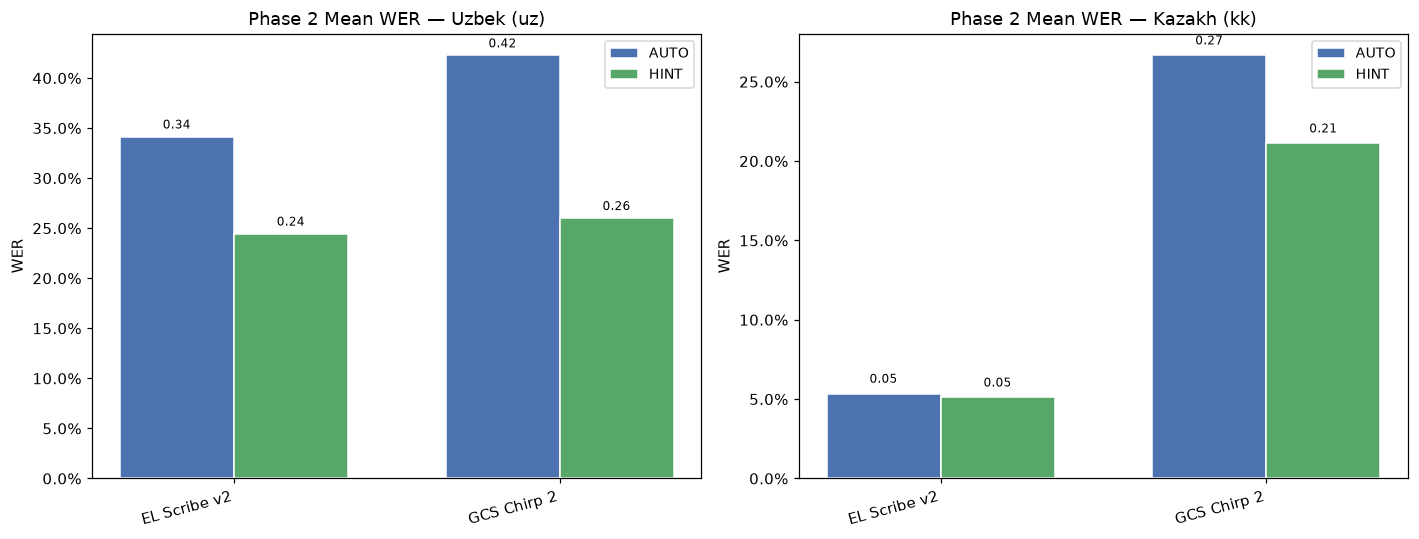

Saved: C:\Users\erkin\central-asian-voice-benchmark\research\phase3nb_p2_wer_comparison.png


In [15]:
# --- Figure 1: Phase 2 WER by provider, language, condition ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, lang, lang_label in zip(axes, ['uz', 'kk'], ['Uzbek (uz)', 'Kazakh (kk)']):
    sub = df2[df2['language'] == lang]
    grp = (sub.groupby(['provider', 'language_condition'])['wer']
              .mean()
              .unstack('language_condition')
              .rename(columns={'auto': 'AUTO', 'hint': 'HINT'})
              .rename(index={'elevenlabs': 'EL Scribe v2', 'google_cloud_stt': 'GCS Chirp 2'}))
    x   = np.arange(len(grp))
    w   = 0.35
    b1  = ax.bar(x - w/2, grp['AUTO'], w, label='AUTO', color='#4C72B0', edgecolor='white')
    b2  = ax.bar(x + w/2, grp['HINT'], w, label='HINT', color='#55A868', edgecolor='white')
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(grp.index, rotation=15, ha='right')
    ax.set_title(f'Phase 2 Mean WER — {lang_label}')
    ax.set_ylabel('WER')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

plt.tight_layout()
out1 = FIG_PATH / 'phase3nb_p2_wer_comparison.png'
plt.savefig(out1, dpi=120)
plt.show()
print(f'Saved: {out1}')

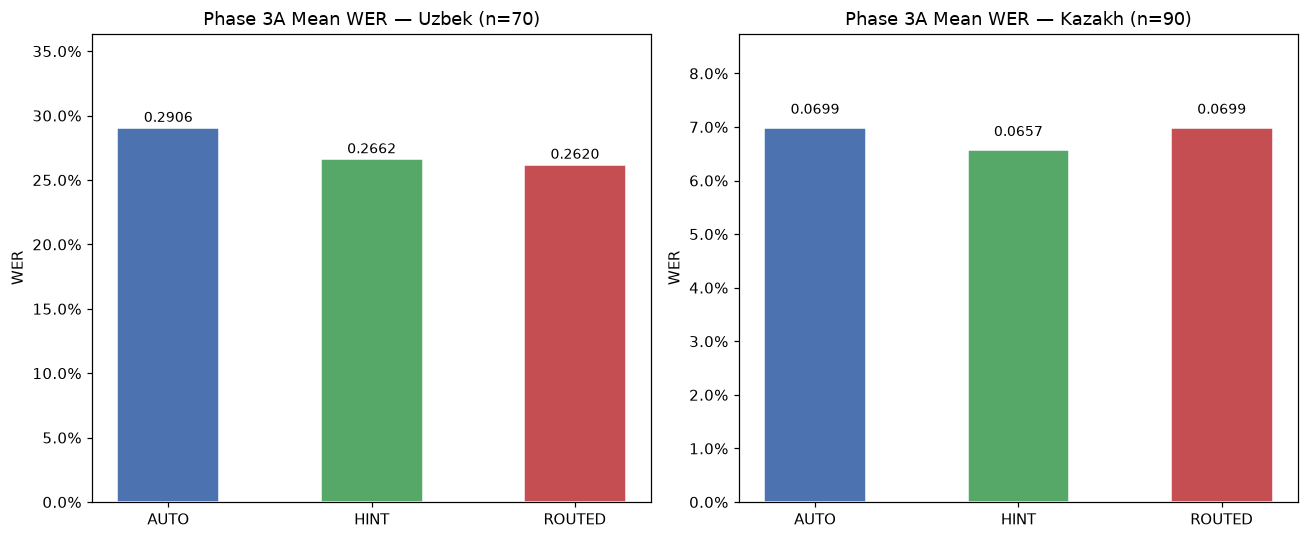

Saved: C:\Users\erkin\central-asian-voice-benchmark\research\phase3nb_p3a_wer_by_condition.png


In [16]:
# --- Figure 2: Phase 3A WER by condition (AUTO / HINT / ROUTED) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cond_colors = {'AUTO': '#4C72B0', 'HINT': '#55A868', 'ROUTED': '#C44E52'}

for ax, lang, uids, auto_d, hint_d, routed_d, lang_label in [
    (axes[0], 'uz', uz_uids, uz_auto_d, uz_hint_d, uz_routed, 'Uzbek (n=70)'),
    (axes[1], 'kk', kk_uids, kk_auto_d, kk_hint_d, kk_routed, 'Kazakh (n=90)'),
]:
    vals = {
        'AUTO':   np.mean([auto_d[uid]['wer']  for uid in uids]),
        'HINT':   np.mean([hint_d[uid]['wer']  for uid in uids]),
        'ROUTED': np.mean([routed_d[uid][0]    for uid in uids]),
    }
    colors = [cond_colors[k] for k in vals]
    bars = ax.bar(list(vals.keys()), list(vals.values()), color=colors, edgecolor='white', width=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Phase 3A Mean WER — {lang_label}')
    ax.set_ylabel('WER')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, max(vals.values()) * 1.25)

plt.tight_layout()
out2 = FIG_PATH / 'phase3nb_p3a_wer_by_condition.png'
plt.savefig(out2, dpi=120)
plt.show()
print(f'Saved: {out2}')

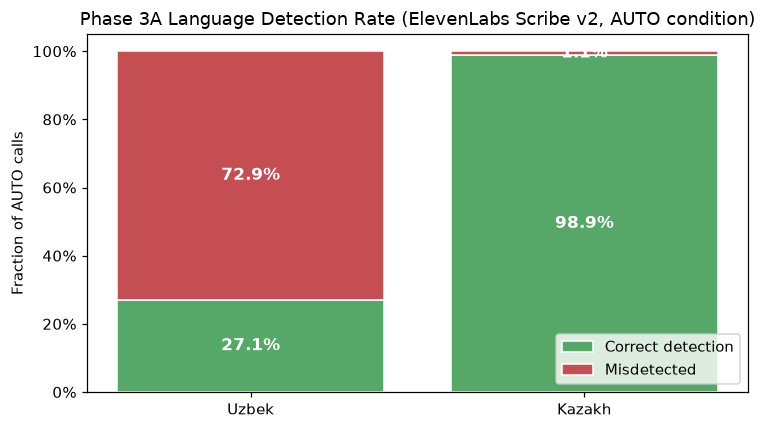

Saved: C:\Users\erkin\central-asian-voice-benchmark\research\phase3nb_p3a_detection_rates.png

Uzbek detection: 19/70 = 27.1% correct (73% misdetected — primarily Turkish, English)
Kazakh detection: 89/90 = 98.9% correct (1 misdetection: Ukrainian)


In [17]:
# --- Figure 3: Language detection rates (Phase 3A AUTO condition) ---
fig, ax = plt.subplots(figsize=(7, 4))

langs   = ['Uzbek', 'Kazakh']
correct = [19/70, 89/90]
wrong   = [1 - c for c in correct]

x = np.arange(len(langs))
ax.bar(x, correct, label='Correct detection', color='#55A868', edgecolor='white')
ax.bar(x, wrong, bottom=correct, label='Misdetected', color='#C44E52', edgecolor='white')

for i, (c, l) in enumerate(zip(correct, langs)):
    ax.text(i, c / 2, f'{c:.1%}', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    ax.text(i, c + (1 - c) / 2, f'{1-c:.1%}', ha='center', va='center', color='white', fontweight='bold', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.set_ylabel('Fraction of AUTO calls')
ax.set_title('Phase 3A Language Detection Rate (ElevenLabs Scribe v2, AUTO condition)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='lower right')
plt.tight_layout()
out3 = FIG_PATH / 'phase3nb_p3a_detection_rates.png'
plt.savefig(out3, dpi=120)
plt.show()
print(f'Saved: {out3}')
print()
print('Uzbek detection: 19/70 = 27.1% correct (73% misdetected — primarily Turkish, English)')
print('Kazakh detection: 89/90 = 98.9% correct (1 misdetection: Ukrainian)')

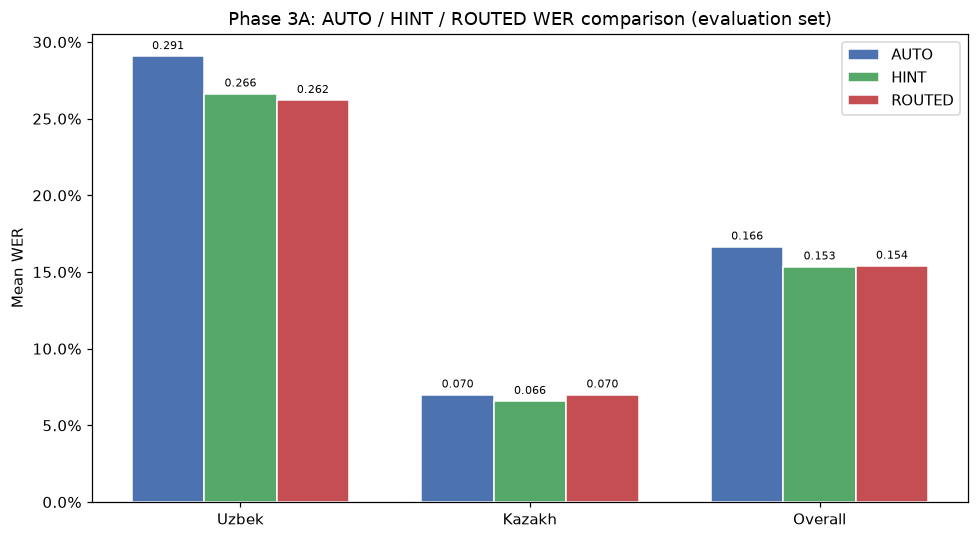

Saved: C:\Users\erkin\central-asian-voice-benchmark\research\phase3nb_p3a_routing_delta.png


In [18]:
# --- Figure 4: Phase 3A routing improvement (routed vs AUTO, routed vs HINT) ---
fig, ax = plt.subplots(figsize=(9, 5))

lang_labels = ['Uzbek', 'Kazakh', 'Overall']
wer_auto_v   = [0.2906, 0.0699, 0.1664]
wer_hint_v   = [0.2662, 0.0657, 0.1534]
wer_routed_v = [0.2620, 0.0699, 0.1539]

x  = np.arange(len(lang_labels))
w  = 0.25
ax.bar(x - w,   wer_auto_v,   w, label='AUTO',   color='#4C72B0', edgecolor='white')
ax.bar(x,       wer_hint_v,   w, label='HINT',   color='#55A868', edgecolor='white')
ax.bar(x + w,   wer_routed_v, w, label='ROUTED', color='#C44E52', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(lang_labels)
ax.set_ylabel('Mean WER')
ax.set_title('Phase 3A: AUTO / HINT / ROUTED WER comparison (evaluation set)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()

# Add value labels
for bars_x, vals in [(x - w, wer_auto_v), (x, wer_hint_v), (x + w, wer_routed_v)]:
    for xi, v in zip(bars_x, vals):
        ax.text(xi, v + 0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
out4 = FIG_PATH / 'phase3nb_p3a_routing_delta.png'
plt.savefig(out4, dpi=120)
plt.show()
print(f'Saved: {out4}')

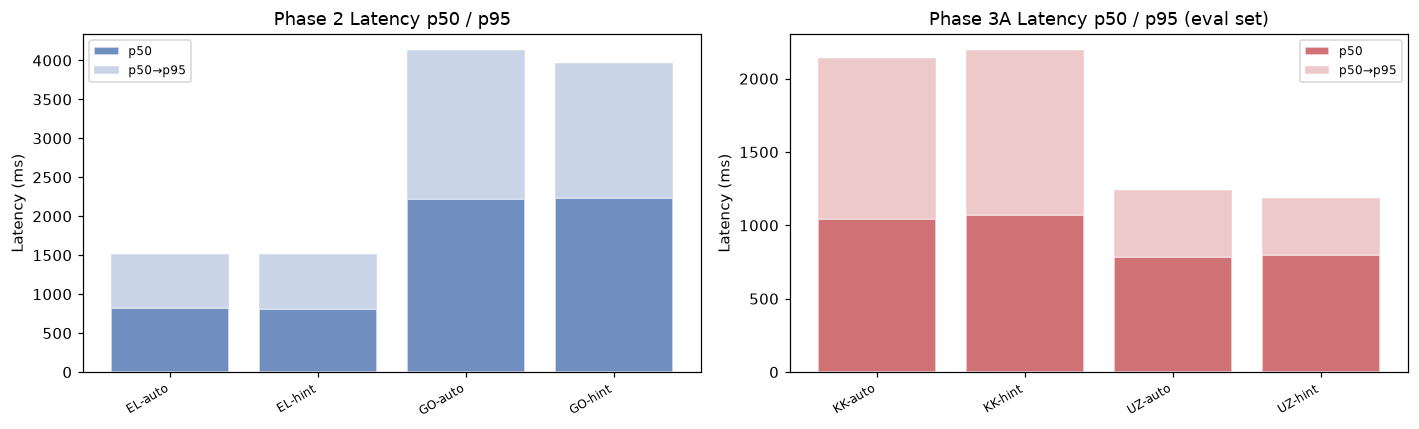

Saved: C:\Users\erkin\central-asian-voice-benchmark\research\phase3nb_latency.png


In [19]:
# --- Figure 5: Latency comparison (Phase 2 + Phase 3A) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Phase 2 latency
p2_lat = df2.groupby(['provider', 'language_condition'])['latency_ms'].agg(
    p50=lambda x: x.quantile(0.5),
    p95=lambda x: x.quantile(0.95)
).reset_index()
ax = axes[0]
labels = [f'{r.provider[:2].upper()}-{r.language_condition}'
          for _, r in p2_lat.iterrows()]
ax.bar(range(len(labels)), p2_lat['p50'], label='p50', color='#4C72B0', edgecolor='white', alpha=0.8)
ax.bar(range(len(labels)), p2_lat['p95'] - p2_lat['p50'],
       bottom=p2_lat['p50'], label='p50→p95', color='#4C72B0', edgecolor='white', alpha=0.3)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Latency (ms)')
ax.set_title('Phase 2 Latency p50 / p95')
ax.legend(fontsize=8)

# Phase 3A latency
p3a_lat = df3.groupby(['language', 'language_condition'])['latency_ms'].agg(
    p50='median',
    p95=lambda x: x.quantile(0.95)
).reset_index()
ax = axes[1]
labels3 = [f'{r.language.upper()}-{r.language_condition}'
           for _, r in p3a_lat.iterrows()]
ax.bar(range(len(labels3)), p3a_lat['p50'], label='p50', color='#C44E52', edgecolor='white', alpha=0.8)
ax.bar(range(len(labels3)), p3a_lat['p95'] - p3a_lat['p50'],
       bottom=p3a_lat['p50'], label='p50→p95', color='#C44E52', edgecolor='white', alpha=0.3)
ax.set_xticks(range(len(labels3)))
ax.set_xticklabels(labels3, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Latency (ms)')
ax.set_title('Phase 3A Latency p50 / p95 (eval set)')
ax.legend(fontsize=8)

plt.tight_layout()
out5 = FIG_PATH / 'phase3nb_latency.png'
plt.savefig(out5, dpi=120)
plt.show()
print(f'Saved: {out5}')

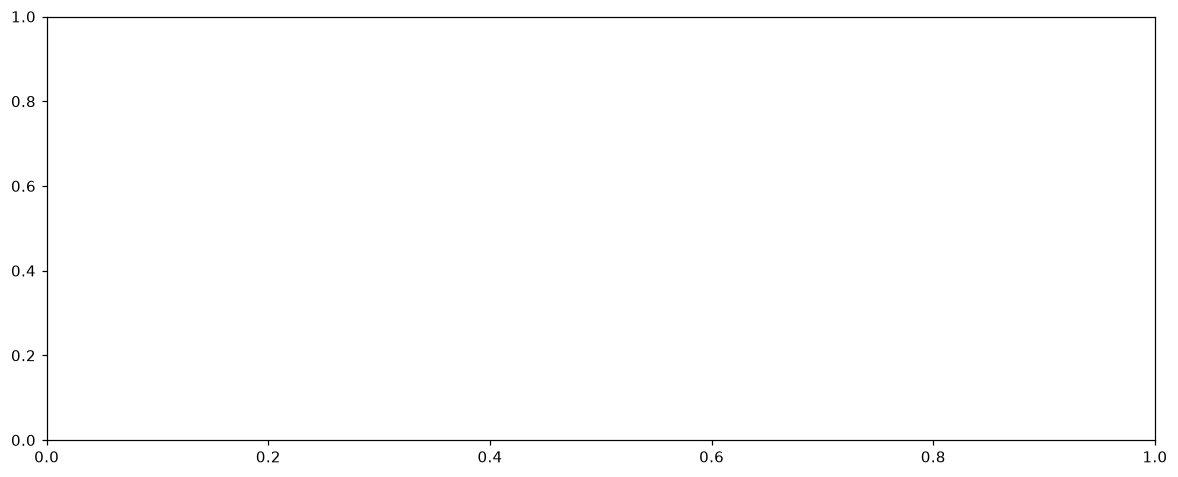

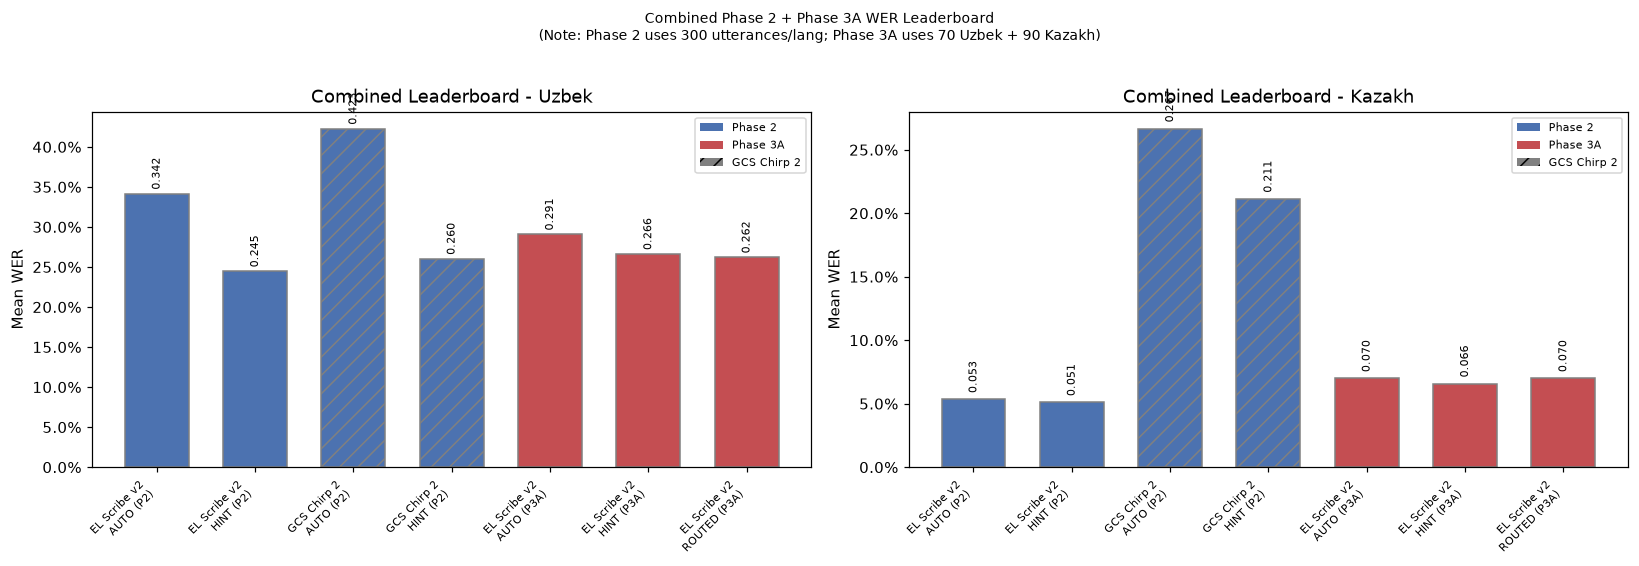

Saved: C:\Users\erkin\central-asian-voice-benchmark\research\phase3nb_combined_leaderboard.png


In [20]:
# --- Figure 6: Combined leaderboard bar chart ---
fig, ax = plt.subplots(figsize=(13, 5))

# Build combined leaderboard rows
leaderboard_rows = [
    # label, language, phase, wer
    ('EL Scribe v2\nAUTO (P2)',   'uz', 'Phase 2', 0.3416),
    ('EL Scribe v2\nHINT (P2)',   'uz', 'Phase 2', 0.2446),
    ('GCS Chirp 2\nAUTO (P2)',    'uz', 'Phase 2', 0.4227),
    ('GCS Chirp 2\nHINT (P2)',    'uz', 'Phase 2', 0.2602),
    ('EL Scribe v2\nAUTO (P3A)',  'uz', 'Phase 3A', 0.2906),
    ('EL Scribe v2\nHINT (P3A)',  'uz', 'Phase 3A', 0.2662),
    ('EL Scribe v2\nROUTED (P3A)','uz', 'Phase 3A', 0.2620),
    ('EL Scribe v2\nAUTO (P2)',   'kk', 'Phase 2', 0.0534),
    ('EL Scribe v2\nHINT (P2)',   'kk', 'Phase 2', 0.0510),
    ('GCS Chirp 2\nAUTO (P2)',    'kk', 'Phase 2', 0.2666),
    ('GCS Chirp 2\nHINT (P2)',    'kk', 'Phase 2', 0.2112),
    ('EL Scribe v2\nAUTO (P3A)',  'kk', 'Phase 3A', 0.0699),
    ('EL Scribe v2\nHINT (P3A)',  'kk', 'Phase 3A', 0.0657),
    ('EL Scribe v2\nROUTED (P3A)','kk', 'Phase 3A', 0.0699),
]

# Uzbek subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, lang, lang_label in zip(axes, ['uz', 'kk'], ['Uzbek', 'Kazakh']):
    sub = [(r[0], r[3]) for r in leaderboard_rows if r[1] == lang]
    labels_lb = [s[0] for s in sub]
    wers_lb   = [s[1] for s in sub]
    colors_lb = ['#4C72B0' if 'P2' in l else '#C44E52' for l in labels_lb]
    hatches   = ['//' if 'GCS' in l else '' for l in labels_lb]

    bars = ax.bar(range(len(labels_lb)), wers_lb, color=colors_lb, edgecolor='grey',
                  width=0.65, hatch='')
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    for i, v in enumerate(wers_lb):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

    ax.set_xticks(range(len(labels_lb)))
    ax.set_xticklabels(labels_lb, rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel('Mean WER')
    ax.set_title(f'Combined Leaderboard - {lang_label}')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4C72B0', label='Phase 2'),
        Patch(facecolor='#C44E52', label='Phase 3A'),
        Patch(facecolor='grey', hatch='//', label='GCS Chirp 2'),
    ]
    ax.legend(handles=legend_elements, fontsize=7.5, loc='upper right')

plt.suptitle('Combined Phase 2 + Phase 3A WER Leaderboard\n'
             '(Note: Phase 2 uses 300 utterances/lang; Phase 3A uses 70 Uzbek + 90 Kazakh)',
             fontsize=9, y=1.02)
plt.tight_layout()
out6 = FIG_PATH / 'phase3nb_combined_leaderboard.png'
plt.savefig(out6, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {out6}')

## 12. Combined Leaderboard (Phase 2 + Phase 3A)

**Important note on comparability:** Phase 2 and Phase 3A use disjoint utterance sets from the same corpus (ISSAI USC v1 for Uzbek, ISSAI KSC 335RS for Kazakh), so WER values are not directly comparable across phases due to different utterance samples. Phase 3A uses a smaller evaluation set (70 Uzbek + 90 Kazakh) compared to Phase 2 (300 Uzbek + 300 Kazakh per provider). Comparisons within a phase are valid; cross-phase comparisons are indicative only.

In [21]:
leaderboard = pd.DataFrame([
    # Phase 2 rows
    {'phase': 'Phase 2', 'provider':   'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'AUTO',   'language': 'uz', 'n': 300, 'wer': 0.3416, 'cer': 0.1491},
    {'phase': 'Phase 2', 'provider':   'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'HINT',   'language': 'uz', 'n': 300, 'wer': 0.2446, 'cer': 0.0937},
    {'phase': 'Phase 2', 'provider':   'GCS',          'model': 'Chirp 2',
     'condition': 'AUTO',   'language': 'uz', 'n': 300, 'wer': 0.4227, 'cer': 0.1754},
    {'phase': 'Phase 2', 'provider':   'GCS',          'model': 'Chirp 2',
     'condition': 'HINT',   'language': 'uz', 'n': 300, 'wer': 0.2602, 'cer': 0.0894},
    {'phase': 'Phase 2', 'provider':   'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'AUTO',   'language': 'kk', 'n': 300, 'wer': 0.0534, 'cer': 0.0140},
    {'phase': 'Phase 2', 'provider':   'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'HINT',   'language': 'kk', 'n': 300, 'wer': 0.0510, 'cer': 0.0137},
    {'phase': 'Phase 2', 'provider':   'GCS',          'model': 'Chirp 2',
     'condition': 'AUTO',   'language': 'kk', 'n': 300, 'wer': 0.2666, 'cer': 0.1361},
    {'phase': 'Phase 2', 'provider':   'GCS',          'model': 'Chirp 2',
     'condition': 'HINT',   'language': 'kk', 'n': 300, 'wer': 0.2112, 'cer': 0.0847},
    # Phase 3A rows (eval set)
    {'phase': 'Phase 3A', 'provider':  'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'AUTO',   'language': 'uz', 'n': 70,  'wer': 0.2906, 'cer': 0.1392},
    {'phase': 'Phase 3A', 'provider':  'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'HINT',   'language': 'uz', 'n': 70,  'wer': 0.2662, 'cer': 0.1190},
    {'phase': 'Phase 3A', 'provider':  'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'ROUTED', 'language': 'uz', 'n': 70,  'wer': 0.2620, 'cer': None},
    {'phase': 'Phase 3A', 'provider':  'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'AUTO',   'language': 'kk', 'n': 90,  'wer': 0.0699, 'cer': 0.0216},
    {'phase': 'Phase 3A', 'provider':  'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'HINT',   'language': 'kk', 'n': 90,  'wer': 0.0657, 'cer': 0.0198},
    {'phase': 'Phase 3A', 'provider':  'ElevenLabs',   'model': 'Scribe v2',
     'condition': 'ROUTED', 'language': 'kk', 'n': 90,  'wer': 0.0699, 'cer': None},
])

print('Combined Phase 2 + Phase 3A Leaderboard:')
print('(Sorted by language, then WER within each language)')
print()
for lang in ['uz', 'kk']:
    sub = leaderboard[leaderboard['language'] == lang].sort_values('wer')
    print(f'--- {lang.upper()} ---')
    print(sub[['phase', 'provider', 'model', 'condition', 'n', 'wer', 'cer']].to_string(index=False))
    print()

Combined Phase 2 + Phase 3A Leaderboard:
(Sorted by language, then WER within each language)

--- UZ ---
   phase   provider     model condition   n    wer    cer
 Phase 2 ElevenLabs Scribe v2      HINT 300 0.2446 0.0937
 Phase 2        GCS   Chirp 2      HINT 300 0.2602 0.0894
Phase 3A ElevenLabs Scribe v2    ROUTED  70 0.2620    NaN
Phase 3A ElevenLabs Scribe v2      HINT  70 0.2662 0.1190
Phase 3A ElevenLabs Scribe v2      AUTO  70 0.2906 0.1392
 Phase 2 ElevenLabs Scribe v2      AUTO 300 0.3416 0.1491
 Phase 2        GCS   Chirp 2      AUTO 300 0.4227 0.1754

--- KK ---
   phase   provider     model condition   n    wer    cer
 Phase 2 ElevenLabs Scribe v2      HINT 300 0.0510 0.0137
 Phase 2 ElevenLabs Scribe v2      AUTO 300 0.0534 0.0140
Phase 3A ElevenLabs Scribe v2      HINT  90 0.0657 0.0198
Phase 3A ElevenLabs Scribe v2      AUTO  90 0.0699 0.0216
Phase 3A ElevenLabs Scribe v2    ROUTED  90 0.0699    NaN
 Phase 2        GCS   Chirp 2      HINT 300 0.2112 0.0847
 Phase 2     

## 13. Key Findings

Findings are classified as:
- **Statistically supported**: p < 0.05 on the pre-specified test
- **Descriptive**: observed in the data but not statistically significant at α = 0.05
- **Inconclusive**: directional but insufficient evidence

In [22]:
findings = [
    {
        'category': 'PRIMARY — statistically supported',
        'finding':  'R1 routing did not demonstrate a statistically significant advantage over '
                    'always-HINT. PRIMARY overall: mean(d)=+0.0005, p=0.820. '
                    'Neither success criterion was met (mean(d) <= -0.030 AND p < 0.05).',
    },
    {
        'category': 'Descriptive (Phase 3A)',
        'finding':  'Uzbek auto-detection rate is 27.1% (19/70). '
                    'Kazakh detection rate is 98.9% (89/90). '
                    'Low Uzbek detection drives the AUTO vs HINT gap.',
    },
    {
        'category': 'Descriptive (Phase 3A)',
        'finding':  'R1 routing triggers 73% of the time for Uzbek (51/70 utterances) '
                    'and 1% for Kazakh (1/90). '
                    'Routing reduces overall WER from 0.1664 (AUTO) to 0.1539 '
                    '(-7.5% relative), matching HINT (0.1534) closely.',
    },
    {
        'category': 'SECONDARY — inconclusive (p=0.075)',
        'finding':  'HINT directionally outperforms AUTO overall: mean(d)=+0.013, p=0.075. '
                    'Does not reach alpha=0.05. Uzbek contributes most of the signal (p=0.103 alone). '
                    'Kazakh shows negligible benefit (p=0.245).',
    },
    {
        'category': 'Descriptive (Phase 3A)',
        'finding':  '15 evaluation records have WER >= 1.0, all Uzbek, all caused by '
                    'script errors (Cyrillic output for Latin-script Uzbek).',
    },
    {
        'category': 'Descriptive (Phase 2)',
        'finding':  'ElevenLabs Scribe v2 outperforms GCS Chirp 2 on both languages under both conditions. '
                    'Kazakh WER is substantially lower than Uzbek across all providers and conditions.',
    },
    {
        'category': 'Descriptive (Phase 2)',
        'finding':  'HINT provides the largest improvement for Uzbek with GCS Chirp 2 '
                    '(0.4227 → 0.2602, -38% relative) and ElevenLabs '
                    '(0.3416 → 0.2446, -28% relative). '
                    'Kazakh benefit is smaller (EL: 0.0534 → 0.0510, -5%).',
    },
    {
        'category': 'Descriptive (cost)',
        'finding':  'Phase 2 total spend: $6.796 (EL $0.433, GCS $6.363). '
                    'Phase 3A total spend: $0.150 (EL only). '
                    'GCS is ~15× more expensive per call than ElevenLabs in this benchmark.',
    },
]

for f in findings:
    print(f"[{f['category']}]\n  {f['finding']}\n")

[PRIMARY — statistically supported]
  R1 routing did not demonstrate a statistically significant advantage over always-HINT. PRIMARY overall: mean(d)=+0.0005, p=0.820. Neither success criterion was met (mean(d) <= -0.030 AND p < 0.05).

[Descriptive (Phase 3A)]
  Uzbek auto-detection rate is 27.1% (19/70). Kazakh detection rate is 98.9% (89/90). Low Uzbek detection drives the AUTO vs HINT gap.

[Descriptive (Phase 3A)]
  R1 routing triggers 73% of the time for Uzbek (51/70 utterances) and 1% for Kazakh (1/90). Routing reduces overall WER from 0.1664 (AUTO) to 0.1539 (-7.5% relative), matching HINT (0.1534) closely.

[SECONDARY — inconclusive (p=0.075)]
  HINT directionally outperforms AUTO overall: mean(d)=+0.013, p=0.075. Does not reach alpha=0.05. Uzbek contributes most of the signal (p=0.103 alone). Kazakh shows negligible benefit (p=0.245).

[Descriptive (Phase 3A)]
  15 evaluation records have WER >= 1.0, all Uzbek, all caused by script errors (Cyrillic output for Latin-script Uzb

## 14. Limitations

1. **Corpus size**: Phase 3A uses 70 Uzbek + 90 Kazakh evaluation utterances. This is a small sample; individual utterance-level effects dominate variance. Effect sizes of clinical significance may be undetectable at this scale.

2. **Evaluation split deviation**: Phase 3A plan anticipated 60 Uzbek + 100 Kazakh evaluation utterances. The actual split is 70 + 90 due to pilot strata (30 Uzbek + 10 Kazakh in pilot). This is a minor deviation but all analyses use the actual counts.

3. **Single provider (Phase 3A)**: Phase 3A covers ElevenLabs Scribe v2 only. Routing findings may not generalise to other providers.

4. **Apostrophe confound**: 7 of 70 Uzbek HINT evaluation records show elevated WER due to apostrophe stripping in normalisation. This inflates HINT WER estimates for those specific utterances.

5. **Utterance set disjointness**: Phase 2 and Phase 3A use disjoint utterance sets from the same corpus. Cross-phase WER comparisons are indicative only; they may reflect corpus differences as well as provider/condition differences.

6. **Duration skew (Uzbek)**: Uzbek Phase 3A is skewed toward short utterances (71% short vs 46% planned) because many USC speakers were fully exhausted by Phase 2. Short utterances have higher WER.

7. **Corpus contamination**: ISSAI USC is rated MEDIUM contamination risk. Web-sourced training data may include portions of this corpus.

8. **Phase 3B deferred**: Azure Speech Fast Transcription benchmarking was deferred due to unresolved pricing and missing API credentials. No Azure results are included.

9. **Phase 2 corpus pooling**: Phase 2 WER values pool across all 300 utterances per language per condition. The leaderboard combines providers evaluated on the same utterance set, making Phase 2 provider comparisons valid. Phase 2 vs Phase 3A comparisons are on different utterance sets.

## 15. Reproducibility Check

This section verifies that all key aggregate values computed in this notebook match the frozen benchmark report within stated precision.

In [23]:
import hashlib

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            h.update(chunk)
    return h.hexdigest()

print('=== Data File Integrity ===')
for path in [P2_PATH, P3A_PATH]:
    size = path.stat().st_size
    sha  = sha256_file(path)
    print(f'  {path.name}: {size:,} bytes  sha256={sha[:32]}...')

print()
print('=== Record Counts ===')
print(f'  Phase 2  total records  : {len(p2_raw):>5d}  (expected 2400)')
print(f'  Phase 3A total records  : {len(p3a_raw):>5d}  (expected 468)')
print(f'  Phase 3A successful     : {len(p3a_all_ok):>5d}  (expected 400)')
print(f'  Phase 3A pilot          : {len(p3a_pilot):>5d}  (expected 80)')
print(f'  Phase 3A eval           : {len(p3a_eval):>5d}  (expected 320 = 160 utterances × 2)')
print(f'  Phase 3A eval Uzbek     : {sum(1 for r in p3a_eval if r["language"]=="uz" and r["language_condition"]=="auto"):>5d}  (expected 70)')
print(f'  Phase 3A eval Kazakh    : {sum(1 for r in p3a_eval if r["language"]=="kk" and r["language_condition"]=="auto"):>5d}  (expected 90)')

print()
print('=== Key Aggregate Values vs Frozen Report ===')

checks = [
    # (description, computed_value, expected_value, tolerance)
    ('Phase2 EL uz  AUTO WER',  float(df2[(df2.provider=='elevenlabs')&(df2.language=='uz')&(df2.language_condition=='auto')]['wer'].mean()),  0.3416, 0.0001),
    ('Phase2 EL uz  HINT WER',  float(df2[(df2.provider=='elevenlabs')&(df2.language=='uz')&(df2.language_condition=='hint')]['wer'].mean()),  0.2446, 0.0001),
    ('Phase2 EL kk  AUTO WER',  float(df2[(df2.provider=='elevenlabs')&(df2.language=='kk')&(df2.language_condition=='auto')]['wer'].mean()),  0.0534, 0.0001),
    ('Phase2 EL kk  HINT WER',  float(df2[(df2.provider=='elevenlabs')&(df2.language=='kk')&(df2.language_condition=='hint')]['wer'].mean()),  0.0510, 0.0001),
    ('Phase2 GCS uz AUTO WER',  float(df2[(df2.provider=='google_cloud_stt')&(df2.language=='uz')&(df2.language_condition=='auto')]['wer'].mean()), 0.4227, 0.0001),
    ('Phase2 GCS uz HINT WER',  float(df2[(df2.provider=='google_cloud_stt')&(df2.language=='uz')&(df2.language_condition=='hint')]['wer'].mean()), 0.2602, 0.0001),
    ('Phase2 GCS kk AUTO WER',  float(df2[(df2.provider=='google_cloud_stt')&(df2.language=='kk')&(df2.language_condition=='auto')]['wer'].mean()), 0.2666, 0.0001),
    ('Phase2 GCS kk HINT WER',  float(df2[(df2.provider=='google_cloud_stt')&(df2.language=='kk')&(df2.language_condition=='hint')]['wer'].mean()), 0.2112, 0.0001),
    ('Phase2 total spend',      float(df2['cost_usd'].sum()),                                                                                   6.7962, 0.0001),
    ('Phase3A uz AUTO WER',     float(df3[(df3.language=='uz')&(df3.language_condition=='auto')]['wer'].mean()),                               0.2906, 0.0001),
    ('Phase3A uz HINT WER',     float(df3[(df3.language=='uz')&(df3.language_condition=='hint')]['wer'].mean()),                               0.2662, 0.0001),
    ('Phase3A kk AUTO WER',     float(df3[(df3.language=='kk')&(df3.language_condition=='auto')]['wer'].mean()),                               0.0699, 0.0001),
    ('Phase3A kk HINT WER',     float(df3[(df3.language=='kk')&(df3.language_condition=='hint')]['wer'].mean()),                               0.0657, 0.0001),
    ('Phase3A total spend',     float(pd.DataFrame(p3a_all_ok)['cost_usd'].sum()),                                                             0.14973, 0.0001),
    ('Phase3A uz routed WER',   float(np.mean([uz_routed[uid][0] for uid in uz_uids])),                                                        0.2620, 0.0001),
    ('Phase3A kk routed WER',   float(np.mean([kk_routed[uid][0] for uid in kk_uids])),                                                        0.0699, 0.0001),
    ('PRIMARY overall mean(d)', float(np.mean(all_primary_d)),                                                                                 0.000470, 0.00001),
    ('PRIMARY overall p',       float(wilcoxon(all_primary_d, alternative='less')[1]),                                                         0.8199, 0.002),
    ('SECONDARY overall p',     float(wilcoxon(all_sec_d,     alternative='greater')[1]),                                                      0.0749, 0.002),
    ('SECONDARY Uzbek p',       float(wilcoxon(uz_sec_d,      alternative='greater')[1]),                                                      0.1025, 0.002),
    ('SECONDARY Kazakh p',      float(wilcoxon(kk_sec_d,      alternative='greater')[1]),                                                      0.2448, 0.002),
]

all_pass = True
for desc, computed, expected, tol in checks:
    ok = abs(computed - expected) <= tol
    status = 'PASS' if ok else 'FAIL'
    if not ok:
        all_pass = False
    print(f'  {status}  {desc:<35s}  computed={computed:.6f}  expected={expected:.6f}  diff={abs(computed-expected):.6f}')

print()
print(f'Overall reproducibility check: {"ALL PASS" if all_pass else "FAILURES DETECTED"}')

=== Data File Integrity ===
  phase2_trackb_results.jsonl: 3,330,020 bytes  sha256=6a0415cc931352e9668d6304b3a21800...
  phase3a_trackb_results.jsonl: 714,970 bytes  sha256=8c1cfa6e9b9c03bb5cc9b90b8a311676...

=== Record Counts ===
  Phase 2  total records  :  2400  (expected 2400)
  Phase 3A total records  :   468  (expected 468)
  Phase 3A successful     :   400  (expected 400)
  Phase 3A pilot          :    80  (expected 80)
  Phase 3A eval           :   320  (expected 320 = 160 utterances × 2)
  Phase 3A eval Uzbek     :    70  (expected 70)
  Phase 3A eval Kazakh    :    90  (expected 90)

=== Key Aggregate Values vs Frozen Report ===
  PASS  Phase2 EL uz  AUTO WER               computed=0.341599  expected=0.341600  diff=0.000001
  PASS  Phase2 EL uz  HINT WER               computed=0.244639  expected=0.244600  diff=0.000039
  PASS  Phase2 EL kk  AUTO WER               computed=0.053430  expected=0.053400  diff=0.000030
  PASS  Phase2 EL kk  HINT WER               computed=0.05102